# Board Game Insights: Data Exploration & Feature Engineering
Welcome! This notebook explores a dataset from BoardGameGeek (BGG), featuring all ranked games in their database as of February 2021.

My goal is to turn messy, real-world data into actionable insights. It sounds just like what I do at work, but I digress! For some reason, using board game data is more fun. This exploratory analysis will lay the groundwork for visualizations and future machine learning models.<br>

---

**Project Roadmap:**

* **Chapter 1. Data Ingestion:** Explore the data in its raw form, establish parsing rules, and define schemas
* **Chapter 2. Data Cleaning:** Drop duplicates, handle nulls, and standardize text features
* **Chapter 3. Exploratory Data Analysis (EDA):** Uncover insights and have fun with visualization libraries!
* **Chapter 4. Feature Engineering:** Prepare the dataset for BI tools and/or predictive modeling

---

Thanks for joining me in this valiant effort. Let's see what we can cook up!


# Chapter 1: Data Ingestion
## Setup and Initialization

In [1]:
# import packages that give me workable data
import pandas as pd
import numpy as np
import pathlib

# import packages that give me pretty data
pd.set_option('display.max_columns', None)     # Remove column limit in displays
from IPython.display import display, Markdown  # Allows me to use Markdown logic as code in my output
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Define the Project Root
current_dir = pathlib.Path.cwd()
ROOT = current_dir.parent

# Define Data Path
DATA_PATH = ROOT / "data" / "bgg_dataset.csv"

# Import CSV
df = pd.read_csv(DATA_PATH, sep=";") # sep is needed since this dataset separates columns with ;

# view sample
print(f"# Columns: {len(df.columns):,}")
print(f"# Rows: {len(df):,}")
print(f"# Unique Board Games: {df['ID'].nunique():,}") # We'll use ID for now since it's the primary key
df.head()

# Columns: 14
# Rows: 20,343
# Unique Board Games: 20,327


,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,161936.0,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,"8,61",2,"2,84",65294.0,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games"
2,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
3,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
4,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"


**For fun, let's view another sample. This time, make it random.**
- df.head() shows the first 5 rows by default, which are usually cleaner due to getting more attention
- Note that this random sample has NaN values

In [2]:
display(df.sample(5))

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
8619,3183.0,Car Wars (Fifth Edition),2002.0,2,2,60,12,228,"6,11",8621,"2,45",470.0,"Dice Rolling, Modular Board, Role Playing, Sim...","Thematic Games, Wargames"
3431,293531.0,Detective: A Modern Crime Board Game - Season One,2020.0,1,5,120,12,377,"7,26",3433,"2,08",1525.0,"Cooperative Game, Solo / Solitaire Game, Story...",Thematic Games
888,94246.0,1812: The Invasion of Canada,2012.0,2,5,90,10,2214,"7,34",889,"2,18",2880.0,"Area Movement, Campaign / Battle Card Driven, ...","Strategy Games, Wargames"
1678,112686.0,Epic Spell Wars of the Battle Wizards: Duel at...,2012.0,2,6,30,15,5550,"6,52",1679,"1,57",10285.0,"Dice Rolling, Hand Management, Take That",Party Games
15338,11924.0,Struggle,1982.0,2,4,40,0,34,"5,94",15340,1,66.0,"Pattern Building, Roll / Spin and Move",NaN


## Initial Inspection
- First, let's get a column summary using using df.info()
- Next, we'll see what quick fixes are possible

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20343 entries, 0 to 20342
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20327 non-null  float64
 1   Name                20343 non-null  object 
 2   Year Published      20342 non-null  float64
 3   Min Players         20343 non-null  int64  
 4   Max Players         20343 non-null  int64  
 5   Play Time           20343 non-null  int64  
 6   Min Age             20343 non-null  int64  
 7   Users Rated         20343 non-null  int64  
 8   Rating Average      20343 non-null  object 
 9   BGG Rank            20343 non-null  int64  
 10  Complexity Average  20343 non-null  object 
 11  Owned Users         20320 non-null  float64
 12  Mechanics           18745 non-null  object 
 13  Domains             10184 non-null  object 
dtypes: float64(3), int64(6), object(5)
memory usage: 2.2+ MB


**Conclusions**
- `ID`, `Year Published` and `Owned Users` don't need to be floats. Later, we'll turn `ID` into a string since it's not meant to be used for math and is simply a randomly generated number. The other two fields should be integers
- `Rating Average` and `Complexity Average` use commas instead of decimal points, which makes pandas interpret them as objects
- `Name`, `Mechanics`, and `Domains` are objects that should be strings (due to having nulls)
- The combination of commas replacing decimal points and a semicolon column separator tells us that this is likely a European dataset. That's useful for data cleaning and provides supporting evidence for who to pressure to play board games with me in my personal life.

We can fix some of this by importing the dataset again and establishing some rules up front!

## The "Smart" Load
- Let's re-read the dataset and establish more rules up front
- In additon, we'll rename columns to use snake case because it's more development-friendly

In [4]:
# Establish custom data types for the problem children using a dictionary:
# Note: Using capital letters (ex: "Int64" vs. "int64") uses the nullable version
# This is useful because standard integers fail if they encounter a null value (nulls prefer floats)
custom_dtypes = {
    'ID': 'string',
    'Year Published': 'Int64',
    'Owned Users': 'Int64'
}

# Ingest data
df = pd.read_csv(
    DATA_PATH,     # We set up these constants earlier, so why not use em?
    sep=";",              # Tells pandas to look for semicolons as the dataset separator
    decimal=",",          # Fixes the '8,5' vs '8.5' issue automatically
    engine="pyarrow",     # Uses the fast arrow engine for reading
    dtype=custom_dtypes,  # Uses the custom dictionary above 
    
    # Let numpy determine the column type for remaining columns.
    # "nullable" tells numpy to keep a column's native type.
    # Otherwise, a single pd.NA would lead the whole column to become a float.
    dtype_backend="numpy_nullable"                                                                          
)

# While we're here, I noticed that the column names, by default, are more fit for displaying than for developing with.
# Let's format them all in snake case. This will give me more coding options, where spaces and upper case letters can cause problems.
# The code below strips white space, makes everything lowercase, and replaces spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')    

df.head()

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains
0,174430,Gloomhaven,2017,1,4,120,14,42055,8.79,1,3.86,68323,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,161936,Pandemic Legacy: Season 1,2015,2,4,60,13,41643,8.61,2,2.84,65294,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games"
2,224517,Brass: Birmingham,2018,2,4,120,14,19217,8.66,3,3.91,28785,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
3,167791,Terraforming Mars,2016,1,5,120,12,64864,8.43,4,3.24,87099,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
4,233078,Twilight Imperium: Fourth Edition,2017,3,6,480,14,13468,8.7,5,4.22,16831,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"


**Confirm it worked:**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20343 entries, 0 to 20342
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  20327 non-null  string 
 1   name                20343 non-null  string 
 2   year_published      20342 non-null  Int64  
 3   min_players         20343 non-null  Int64  
 4   max_players         20343 non-null  Int64  
 5   play_time           20343 non-null  Int64  
 6   min_age             20343 non-null  Int64  
 7   users_rated         20343 non-null  Int64  
 8   rating_average      20343 non-null  Float64
 9   bgg_rank            20343 non-null  Int64  
 10  complexity_average  20343 non-null  Float64
 11  owned_users         20320 non-null  Int64  
 12  mechanics           18745 non-null  string 
 13  domains             10184 non-null  string 
dtypes: Float64(2), Int64(8), string(4)
memory usage: 2.4 MB


**While we're here, let's do a summary stats check**
- In particular, I'm curious about `Users Rated` vs. `Owned Users`. I assume that more users own a game than rate it, but it's find out for sure.

In [6]:
# Create new column for variance between users rated and owned
df['user_gap'] = df['owned_users'] - df['users_rated']

df.describe().style.format("{:,.1f}")

,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,user_gap
count,"20,342.0","20,343.0","20,343.0","20,343.0","20,343.0","20,343.0","20,343.0","20,343.0","20,343.0","20,320.0","20,320.0"
mean,"1,984.2",2.0,5.7,91.3,9.6,841.0,6.4,"10,172.9",2.0,"1,408.5",566.7
std,214.0,0.7,15.2,545.4,3.6,"3,511.6",0.9,"5,872.8",0.8,"5,040.2","1,681.0"
min,"-3,500.0",0.0,0.0,0.0,0.0,30.0,1.1,1.0,0.0,0.0,"-2,560.0"
25%,"2,001.0",2.0,4.0,30.0,8.0,55.0,5.8,"5,087.5",1.3,146.0,76.0
50%,"2,011.0",2.0,4.0,45.0,10.0,120.0,6.4,"10,173.0",2.0,309.0,179.0
75%,"2,016.0",2.0,6.0,90.0,12.0,385.0,7.0,"15,258.5",2.5,864.0,449.0
max,"2,022.0",10.0,999.0,"60,000.0",25.0,"102,214.0",9.6,"20,344.0",5.0,"155,312.0","53,098.0"


**Conclusions**
- First off, we have negative numbers for `Year Published` and `User Gap`! Let's check those out next
- Also, what game has a `Play Time` of 60,000 hours!?
- We have `Min Age` of 0 through 25. I wanna see what games they think babies can play, and which require someone with a fully formed prefrontal cortex
- Speaking of 0s, we also have a 0 min for `Min Players`, `Max Players`, `Play Time`, `Complexity Average`, and `Owned Users` that are worth checking out.

In [7]:
# Check counts for columns with unexpected values
print(f"# rows with <0 Year Published: {len(df[df['year_published'] < 0])}")
print(f"# rows with <0 User Gap: {len(df[df['user_gap'] < 0])}")
# Check counts for columns with 0 values
print(f"# rows with 0 Min Players: {len(df[df['min_players'] == 0]):,}")
print(f"# rows with 0 Max Players: {len(df[df['max_players'] == 0]):,}")
print(f"# rows with 0 Play Time: {len(df[df['play_time'] == 0]):,}")
print(f"# rows with 0 Min Age: {len(df[df['min_age'] == 0]):,}")
print(f"# rows with 0 Complexity: {len(df[df['complexity_average'] == 0]):,}")
print(f"# rows with 0 Owned Users: {len(df[df['owned_users'] == 0]):,}")

# rows with <0 Year Published: 10
# rows with <0 User Gap: 558
# rows with 0 Min Players: 46
# rows with 0 Max Players: 161
# rows with 0 Play Time: 556
# rows with 0 Min Age: 1,251
# rows with 0 Complexity: 426
# rows with 0 Owned Users: 1


In [8]:
# Since <0 Year Published is only 10, let's check them all out!
df[df['year_published'] < 0].head(10)

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
172,188,Go,-2200,2,2,180,8,14843,7.64,173,4.0,20398,"Enclosure, Square Grid",Abstract Games,5555
1275,2397,Backgammon,-3000,2,2,30,8,11680,6.54,1276,2.02,17747,"Advantage Token, Betting and Bluffing, Dice Ro...",Abstract Games,6067
8174,2399,Senet,-3500,2,2,30,6,664,5.82,8176,1.48,1343,"Dice Rolling, Roll / Spin and Move",Abstract Games,679
8924,1602,The Royal Game of Ur,-2600,2,2,30,10,549,5.9,8926,1.31,1162,"Dice Rolling, Roll / Spin and Move, Square Gri...",Abstract Games,613
15134,21488,Petteia,-100,2,2,20,5,51,6.01,15136,2.17,93,"Action Queue, Area Majority / Influence",Abstract Games,42
19648,19915,Three Men's Morris,-1400,2,2,5,5,60,4.31,19650,1.25,60,"Pattern Building, Point to Point Movement",Abstract Games,0
20002,3886,Nine Men's Morris,-1400,2,2,20,6,1310,5.36,20004,1.84,1642,"Pattern Building, Point to Point Movement",Abstract Games,332
20219,5546,Marbles,-3000,1,0,10,4,473,4.69,20221,1.1,399,Flicking,Children's Games,-74
20341,5432,Chutes and Ladders,-200,2,6,30,3,3783,2.86,20343,1.02,4400,"Dice Rolling, Grid Movement, Race, Roll / Spin...",Children's Games,617
20342,11901,Tic-Tac-Toe,-1300,2,2,1,4,3275,2.68,20344,1.16,1374,"Paper-and-Pencil, Pattern Building","Abstract Games, Children's Games",-1901


**Conclusions**
- These games make sense! They're all ancient. We can keep these for now.
- Also, some of these had a negative `User Gap` which makes sense for something like Tic-Tac-Toe, which can be played without owning it.
- Side note, who is rating Tic-Tac-Toe!? I decided to look it up:

![Tic Tac Toe BGG Overview](https://raw.githubusercontent.com/hayworthanalytics/board-game-insights/main/images/tac_tac_toe_bgg.png)
Looking at the overview, I wanna know how they ended up with a background full of The One Ring rip-offs!

Additionally, some of the reviews were fun to read. I love this person's enthusiasm, despite the CATAN trash talking:
![Tic Tac Toe BGG Review Example](https://raw.githubusercontent.com/hayworthanalytics/board-game-insights/main/images/tic_tac_toe_review1.png)

Finally, here is a more balanced review. They even recommeded Ultimate Tic-Tac-Toe AND they used the `ID` as an additional reference point! Not all heroes wear capes.
![Tic Tac Toe BGG Review Example](https://raw.githubusercontent.com/hayworthanalytics/board-game-insights/main/images/tic_tac_toe_review2.png)


<div class="alert alert-block alert-warning">
<b>TODO:</b> Investigate `Min` and `Max` Player = 0
</div>

<div class="alert alert-block alert-warning">
<b>TODO:</b> Investigate `Play Time` = 0
</div>

**Next, let's jump over to the `Min Age` column**

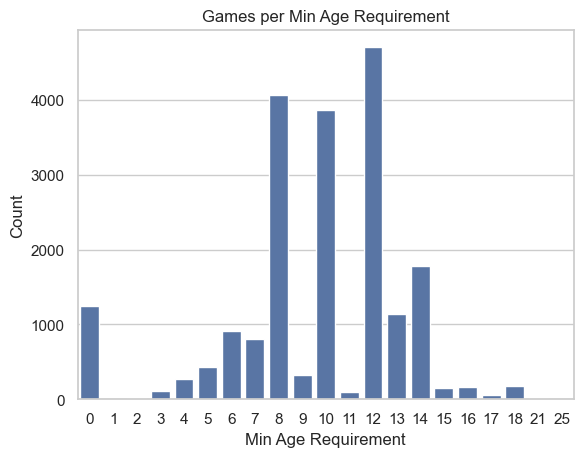

In [9]:
# This calls for a bar chart! Let's see the overall spread.
sns.countplot(data=df, x='min_age', order=sorted(df['min_age'].dropna().unique()))

plt.title('Games per Min Age Requirement')
plt.xlabel('Min Age Requirement')
plt.ylabel('Count')

plt.show()

In [10]:
# The # games that fresh babies can play was pretty surprising. 1,251?? 
# Let's see if those are real, and if so, that'll be good to know next time I meet a baby
# But I kinda suspect it's a data entry error
df.sort_values(by='min_age').head(5)

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
10171,91438,Right Fierce & Terrible: Sluys 1340,2011,2,2,180,0,45,7.19,10173,3.0,295,"Hexagon Grid, Simulation",Wargames,250
10244,38830,Destruction of Army Group Center (Second Edition),2009,2,2,180,0,61,6.87,10246,2.54,258,"Dice Rolling, Hexagon Grid, Simulation",Wargames,197
10249,25617,Korona,0,2,4,15,0,124,6.14,10251,1.18,59,<NA>,<NA>,-65
10271,251026,Night Drop 2: Pegasus Bridge,2018,2,2,120,0,39,7.58,10273,3.25,224,"Dice Rolling, Hexagon Grid, Movement Points, R...",Wargames,185
10278,36612,Great War at Sea: Pacific Crossroads,2010,2,2,30,0,51,7.14,10280,2.57,240,Hexagon Grid,Wargames,189


**Conclusions**
- `Min Age` = 0 definitely indicates that no age is recorded in this dataset. I just don't believe that babies want to play that many war games.
- Since this column is a nullable integer, I'll replace zeroes with pd.NA. That way, it won't impact future calculations.
- Note: pd.NA won't work with some ML methods, so I'll have to do more feature engineering if I intend to use this dataset for ML in the future. But I'll keep NULLs for data exploration since they're more useful to me in that format for now.

In [11]:
df['min_age'] = df['min_age'].replace(0, pd.NA)

In [12]:
# Let's check games with the oldest min age next
df.sort_values(by=['min_age'], ascending = [False]).head(5)

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
18931,28308,Martinis & Men,2007,2,8,20,25,76,5.0,18933,1.0,99,Dice Rolling,<NA>,23
6144,99655,Swinging Jivecat Voodoo Lounge,2016,2,5,60,21,215,6.57,6146,2.63,616,"Area Majority / Influence, Hand Management, Ne...",<NA>,401
9557,211996,Drinking Fluxx,2017,2,6,40,21,148,6.3,9559,1.0,696,"Hand Management, Set Collection",<NA>,548
15883,123930,Pint Craft,2012,2,6,60,21,48,5.91,15885,1.86,176,Set Collection,<NA>,128
12994,206437,Drinking Quest: Journey into Draught,2016,2,4,90,21,80,6.3,12996,1.25,391,Role Playing,<NA>,311


**Conclusions**
- Only one game has an age > 21 (and of course, it's a matchmaking game!). When I look it up on BGG's website, it has a lower age requirement. It must have been a data entry error.
- Since this is a special case, I'll fix it manually.

In [30]:
df.loc[df["name"] == "Martinis & Men", "min_age"] = 16
df[(df['name'] == "Martinis & Men")]

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
18931,28308,Martinis & Men,2007,2,8,20,16,76,5.0,18933,1.0,99,Dice Rolling,<NA>,23


In [13]:
# I'm also curious about those games with a `Min Age` of 1-3
cond1 = df['min_age'] > 0
cond2 = df['min_age'] < 5
df[(cond1 & cond2)].sort_values(by='min_age').head()

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
10711,136910,Roll & Play,2012,2,2,5,1,75,6.44,10713,1.0,169,Dice Rolling,<NA>,94
10634,299946,Eiyo,2020,1,2,30,1,38,7.48,10636,2.0,445,"Events, Hand Management, Solo / Solitaire Game...",<NA>,407
13822,161773,Little Cooperation,2012,2,4,10,2,78,5.99,13824,1.0,209,"Cooperative Game, Dice Rolling",<NA>,131
16595,67429,Shapes & Colors,2008,1,3,10,2,31,5.7,16597,1.0,69,"Dice Rolling, Pattern Recognition",Children's Games,38
13624,104798,Evening in the Stable,2011,1,4,10,2,49,6.37,13626,1.0,105,Cooperative Game,<NA>,56


**Conclusions**
- Immediately, many of these make sense. I mean, I wouldn't trust every 1-year old with dice, but you do you.
- One of the examples above does stand out to me though: Eiyo. Not only does it have a higher `Complexity Average`, but look at those mechanics! I don't trust a 1-year old to play a SOLO event-based card game. I looked it up, and sure enough, check out the age posted on the live website: 14. This must be a data entry error from the 2021 version of this dataset (but it is fun to think about toddlers managing weapons as a Samurai).

![Tic Tac Toe BGG Overview](https://raw.githubusercontent.com/hayworthanalytics/board-game-insights/main/images/eiyo_bgg.png)

- Let's see if we can capture more data entry errors based on the `Complexity Average`

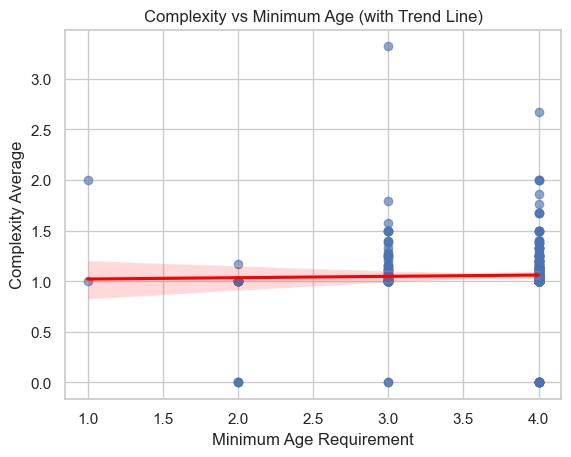

In [14]:
# We'll start with a scatter plot to determine if there are many cases like Eiyo
sns.regplot(
    data=df[(cond1 & cond2)],
    x="min_age",
    y="complexity_average",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Complexity vs Minimum Age (with Trend Line)")
plt.xlabel("Minimum Age Requirement")
plt.ylabel("Complexity Average")
plt.show()

In [15]:
# The scatter plot didn't show too many outliers, though some peak my interest. Let's look at the actual rows:
cond3 = df['complexity_average'] >= 2
df[(cond1 & cond2 & cond3)].sort_values(by=['complexity_average'], ascending=[False])

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
19691,32124,My Little Pony Hide & Seek,2005,2,6,20,3,74,4.82,19693,3.32,41,"Memory, Modular Board",Children's Games,-33
5810,232974,Paco Ŝako,2017,2,2,60,4,111,7.76,5812,2.67,218,Area Majority / Influence,<NA>,107
10634,299946,Eiyo,2020,1,2,30,1,38,7.48,10636,2.0,445,"Events, Hand Management, Solo / Solitaire Game...",<NA>,407
14826,22614,Petróleo,0,2,6,60,4,40,6.13,14828,2.0,64,Card Drafting,<NA>,24
16015,142517,Grabolo,2012,3,5,20,4,79,5.72,16017,2.0,216,"Memory, Pattern Recognition",<NA>,137
17702,3371,September,1985,2,2,20,4,42,5.18,17704,2.0,69,Tile Placement,Abstract Games,27


**Conclusion**
- While "My Little Pony Hide & Seek" has a `Complexity Rating` that could probably stump me, it doesn't strike me as a data entry error like "Eiyo" did. Additionally, "Eiyo" is the only game from this list with a `Min Age` below 3. I will assume for now that "Eiyo" only game from this subset with a data entry error. Therefore, I can give it special attention.

In [16]:
# replace the `Min Age` value for Eiyo with the corrected value
df.loc[df["name"] == "Eiyo", "min_age"] = 14
df[(df['name'] == "Eiyo")]

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
10634,299946,Eiyo,2020,1,2,30,14,38,7.48,10636,2.0,445,"Events, Hand Management, Solo / Solitaire Game...",<NA>,407


<div class="alert alert-block alert-warning">
<b>TODO:</b> Investigate `Play Time` = 0
</div>

**While we're here, let's check out games with a really high play time**

In [17]:
# If I'm gonna force my friends to game with me, these will be great options to ensure I get the most out of it.

df.sort_values(by='play_time', ascending = False).head(5)

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
13420,4815,The Campaign for North Africa: The Desert War ...,1979,8,10,60000,14,146,6.1,13422,4.71,385,"Dice Rolling, Hexagon Grid, Simulation",Wargames,239
3208,29285,Case Blue,2007,2,2,22500,12,289,8.26,3210,4.58,711,"Dice Rolling, Hexagon Grid, Simulation",Wargames,422
6035,46669,1914: Offensive à outrance,2013,2,4,17280,<NA>,108,7.98,6037,4.07,661,"Dice Rolling, Hexagon Grid, Simulation",Wargames,553
7895,158793,Atlantic Wall: D-Day to Falaise,2014,2,6,14400,16,69,8.08,7897,4.89,328,"Hexagon Grid, Zone of Control",Wargames,259
9497,6942,Drang Nach Osten!,1973,2,4,12000,12,77,6.82,9499,4.22,192,"Dice Rolling, Hexagon Grid, Simulation",Wargames,115


**Conclusions**
- aaaaand they're all wargames. That makes sense. No additional steps needed here.

**Now that we've cleaned up some data entry errors, let's check out the summary stats again**

<div class="alert alert-block alert-warning">
<b>TODO:</b> Investigate `Owned Users` = 0
</div>

In [18]:
df.describe().style.format("{:,.1f}")

,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,user_gap
count,"20,342.0","20,343.0","20,343.0","20,343.0","19,092.0","20,343.0","20,343.0","20,343.0","20,343.0","20,320.0","20,320.0"
mean,"1,984.2",2.0,5.7,91.3,10.2,841.0,6.4,"10,172.9",2.0,"1,408.5",566.7
std,214.0,0.7,15.2,545.4,2.8,"3,511.6",0.9,"5,872.8",0.8,"5,040.2","1,681.0"
min,"-3,500.0",0.0,0.0,0.0,1.0,30.0,1.1,1.0,0.0,0.0,"-2,560.0"
25%,"2,001.0",2.0,4.0,30.0,8.0,55.0,5.8,"5,087.5",1.3,146.0,76.0
50%,"2,011.0",2.0,4.0,45.0,10.0,120.0,6.4,"10,173.0",2.0,309.0,179.0
75%,"2,016.0",2.0,6.0,90.0,12.0,385.0,7.0,"15,258.5",2.5,864.0,449.0
max,"2,022.0",10.0,999.0,"60,000.0",25.0,"102,214.0",9.6,"20,344.0",5.0,"155,312.0","53,098.0"


# Chapter 2: Data Cleaning
## Handling Duplicates
- We'll use .duplicated() to check for `ID` duplicates (since it's the primary key) and row duplicates
- **Conclusion:** No dups! However, there are rows with the same `Name` value (more on that below!)

In [19]:
# Check for entire rows
df[df.duplicated()] # No rows are entirely the same

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap


In [20]:
# Check for the primary key specifically
df[df.duplicated(subset=['id'])] # All are NULL! We will likely remove these next.

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
10835,<NA>,Die Erben von Hoax,1999,3,8,45,12,137,6.05,10837,2.0,<NA>,<NA>,<NA>,<NA>
11152,<NA>,Rommel in North Africa: The War in the Desert ...,1986,2,2,0,12,53,6.76,11154,4.0,<NA>,<NA>,<NA>,<NA>
11669,<NA>,Migration: A Story of Generations,2012,2,4,30,12,49,7.2,11671,2.0,<NA>,<NA>,<NA>,<NA>
12649,<NA>,Die Insel der steinernen Wachter,2009,2,4,120,12,49,6.73,12651,3.0,<NA>,<NA>,<NA>,<NA>
12764,<NA>,Dragon Ball Z TCG (2014 edition),2014,2,2,20,8,33,7.03,12766,2.5,<NA>,<NA>,<NA>,<NA>
13282,<NA>,Dwarfest,2014,2,6,45,12,82,6.13,13284,1.75,<NA>,<NA>,<NA>,<NA>
13984,<NA>,Hus,<NA>,2,2,40,<NA>,38,6.28,13986,2.0,<NA>,<NA>,<NA>,<NA>
14053,<NA>,Contrario 2,2006,2,12,0,14,37,6.3,14055,1.0,<NA>,<NA>,<NA>,<NA>
14663,<NA>,Warage: Extended Edition,2017,2,6,90,10,49,7.64,14665,3.0,<NA>,<NA>,<NA>,<NA>
16292,<NA>,Rainbow,2010,2,6,20,8,35,5.65,16294,2.0,<NA>,<NA>,<NA>,<NA>


In [21]:
# Check for game names. I wonder if some names may be shared across different versions.
df_shared_names = df[df.duplicated(subset=['name'], keep=False)].sort_values(by='name')

# Let's see some summary stats
print(f"Total # rows with the same name: {len(df_shared_names)}")
print(f"Total # unique names in subset: {df_shared_names['name'].nunique()}")
print(f"Average # editions per unique name in subset: {len(df_shared_names) / df_shared_names['name'].nunique():.2f}")
print(f"Total % of dataset rows from subset: {len(df_shared_names)/len(df):.1%}")
print(f"Total % of unique names from subset: {df_shared_names['name'].nunique()/df['name'].nunique():.1%}")

df_shared_names.head(6)

Total # rows with the same name: 690
Total # unique names in subset: 323
Average # editions per unique name in subset: 2.14
Total % of dataset rows from subset: 3.4%
Total % of unique names from subset: 1.6%


,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
14684,205495,1001,2016,2,8,45,8,55,6.11,14686,2.0,110,"Action Queue, Grid Movement, Simultaneous Acti...",<NA>,55
13930,17183,1001,1900,2,4,60,12,31,6.43,13932,2.0,15,"Auction/Bidding, Trick-taking",<NA>,-16
9693,11284,1862,2000,4,7,360,12,46,7.35,9695,3.71,72,"Network and Route Building, Stock Holding, Til...",<NA>,26
19215,4456,1862,1990,1,2,180,12,51,4.68,19217,2.38,170,"Dice Rolling, Events, Hexagon Grid, Simulation",Wargames,119
19338,8308,3D Labyrinth,2002,2,4,30,5,138,5.13,19340,1.06,359,Modular Board,Children's Games,221
14751,274205,3D Labyrinth,2019,2,4,30,7,37,6.1,14753,1.5,82,"Modular Board, Network and Route Building, Poi...",<NA>,45


**Conclusions**

- There ARE in fact duplicates for `Name`, BUT other column values can differ. Since I see different `Year Published` values for each duplicate in this sample, I assume that duplicates exist for different editions of the game. However, we'll be sure to confirm that!
- On average, there are slightly over 2 editions per game in this subset. I wonder which games have the most editions?
- From the examples, multiple factors could change across editions:
    - `Min/Max Players` and `Min Age` differences indicate real game changes across editions
    - `Domains` changes could simply come from varying data quality across editions (ex: NULLs in one version but not the other)
- Overall, games with multiple editions account for 3.4% of the entire dataset's rows and 1.6% of its unique names

**Considerations**

Next, I'll answer as many of the above questions as I can. These are the next steps I'm considering:
1. Keep all duplicate `Name` rows, but add a new column for `Full Title` that concatenates `Name` with `Year Published`
2. Remove all but one duplicate `Name` and determine the best method for selection, likely based on max `Year Published` or `Owned Users` (or removing versions with NULLs)

Option 1 works better if we'd like to consider each edition as its own game. Option 2 works better if we're concerned about overweighting any features of duplicates. BUT since I personally know that different editions can vary wildly AND these rows only constitute 3.4% of the entire dataset, I'm leaning towards option 1.

In [22]:
# Let's create a summary table to learn more about games with the same name
df_shared_names_summary = df_shared_names.groupby('name').agg(
    edition_count=('id', 'count'),
    # Check ranges for fields of interest. We can calculate the difference once the dataframe has been made.
    min_year=('year_published','min'),
    max_year=('year_published','max'),
    min_complexity=('complexity_average', 'min'),
    max_complexity=('complexity_average', 'max'),
    # Track whether game meta data changed
    min_player_variants=('min_players','nunique'),
    max_player_variants=('max_players','nunique'),
    play_time_variants=('play_time', 'nunique'),
    min_age_variants=('min_age', 'nunique'),
).reset_index()

# Now let's add more calculations. I'll also use pop() and insert() to place them in a more fitting column order 
# (because otherwise it will drive me CRAZY!!!)
df_shared_names_summary['year_range'] = df_shared_names_summary['max_year'] - df_shared_names_summary['min_year']
df_shared_names_summary.insert(4, 'year_range', df_shared_names_summary.pop('year_range'))
df_shared_names_summary['complexity_range'] = df_shared_names_summary['max_complexity'] - df_shared_names_summary['min_complexity']
df_shared_names_summary.insert(7, 'complexity_range', df_shared_names_summary.pop('complexity_range'))

# On second thought, I don't really care about min and max complexity. I just care about the range. So let's drop those columns!
df_shared_names_summary = df_shared_names_summary.drop(columns = {'min_complexity', 'max_complexity'})


# Top 10 most duplicated names
df_shared_names_summary.sort_values(by=['edition_count', 'name'], ascending = [False, True]).head(10)

,name,edition_count,min_year,max_year,year_range,complexity_range,min_player_variants,max_player_variants,play_time_variants,min_age_variants
240,Robin Hood,6,1990,2019,29,1.0,2,3,4,3
55,Chaos,4,1970,2010,40,0.58,2,4,4,1
71,Cosmic Encounter,4,1977,2008,31,0.33,2,3,3,1
126,Gangster,4,1985,2007,22,0.83,1,3,3,3
128,Gettysburg,4,1958,2018,60,1.48,2,1,4,2
244,Saga,4,1980,2011,31,0.75,2,2,4,2
6,Airlines,3,1990,2016,26,0.94,1,2,3,2
12,Ali Baba,3,1993,2017,24,1.0,1,2,3,3
21,Around the World in 80 Days,3,1986,2016,30,0.17,1,1,2,1
22,Artifact,3,1980,2013,33,0.81,2,3,3,1


In [23]:
df_shared_names_summary.describe().round(1)

,edition_count,min_year,max_year,year_range,complexity_range,min_player_variants,max_player_variants,play_time_variants,min_age_variants
count,323.0,323.0,323.0,323.0,323.0,323.0,323.0,323.0,323.0
mean,2.1,1946.1,2008.5,62.4,0.6,1.4,1.7,1.9,1.7
std,0.4,290.8,11.0,286.4,0.6,0.5,0.5,0.5,0.6
min,2.0,0.0,1953.0,0.0,0.0,1.0,1.0,1.0,0.0
25%,2.0,1979.0,2003.5,8.0,0.2,1.0,1.0,2.0,1.0
50%,2.0,1991.0,2011.0,17.0,0.5,1.0,2.0,2.0,2.0
75%,2.0,2002.0,2017.0,29.0,1.0,2.0,2.0,2.0,2.0
max,6.0,2018.0,2021.0,2001.0,3.3,3.0,4.0,4.0,3.0


## Missing Values (NULLs)
- First, we'll count nulls per column
- Next, we'll inspect samples of the dataset where each column has nulls

In [24]:
# count nulls per column
null_counts = df.isnull().sum().sort_values(ascending=False)

# Filter on columns with nulls
null_counts = null_counts[null_counts > 0]

# Let's turn this series into a dataframe! Why, you ask? She deserves to feel pretty.
display_nulls = (null_counts
    .reset_index(name='Null Count')
    .rename(columns={'index':'Column Name'})
                )

display(Markdown("#### Null count per column with NULLs"))
display(display_nulls)

#### Null count per column with NULLs

,Column Name,Null Count
0,domains,10159
1,mechanics,1598
2,min_age,1251
3,owned_users,23
4,user_gap,23
5,id,16
6,year_published,1


> **Lesson learned from the code below:**
>
> 
> The code below worked in my local Jupyter Notebook, but the red highlights vanished on GitHub previews. This was how I learned that GitHub strips out custom CSS for security reasons.
>
> I've replaced the display_df code below with a version that allows me to see red cells while developing while also forcing GitHub to explicitly write `NaN`. 
>
> For future reference, here is the original code that only works locally:

```python
# This renders red nulls locally, but completely blank cells on GitHub
display_df = df[df[col].isnull()].head().style.highlight_null(color='red')
display(display_df)

In [25]:
# Inspect samples of the dataset where each column has nulls

def inspect_nulls(df):
    # First, list the columns with nulls
    null_counts = df.isnull().sum()
    cols_with_nulls = null_counts[null_counts > 0].index

    # Add condition for no nulls
    if len(cols_with_nulls) == 0:
        display(Markdown("#### Huzzah! No nulls found!"))
        return

    # Loop for null cols
    for col in cols_with_nulls:
        display(Markdown(f"---\n#### Top 5 rows where `{col}` is NULL"))
        display_df = (
            df[df[col].isnull()]
            .head()
            .style
            .format(na_rep="NaN") 
            .highlight_null(color='red')
        )
        display(display_df)

inspect_nulls(df)

---
#### Top 5 rows where `id` is NULL

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
10776,NaN,Ace of Aces: Jet Eagles,1990,2,2,20,10,110,6.260000,10778,2.000000,NaN,NaN,NaN,NaN
10835,NaN,Die Erben von Hoax,1999,3,8,45,12,137,6.050000,10837,2.000000,NaN,NaN,NaN,NaN
11152,NaN,Rommel in North Africa: The War in the Desert 1941-42,1986,2,2,0,12,53,6.760000,11154,4.000000,NaN,NaN,NaN,NaN
11669,NaN,Migration: A Story of Generations,2012,2,4,30,12,49,7.200000,11671,2.000000,NaN,NaN,NaN,NaN
12649,NaN,Die Insel der steinernen Wachter,2009,2,4,120,12,49,6.730000,12651,3.000000,NaN,NaN,NaN,NaN


---
#### Top 5 rows where `year_published` is NULL

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
13984,NaN,Hus,NaN,2,2,40,NaN,38,6.280000,13986,2.000000,NaN,NaN,NaN,NaN


---
#### Top 5 rows where `min_age` is NULL

...

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
1059,85256,Timeline: Inventions,2010,2,8,15,8,7257,6.710000,1060,1.110000,12448,NaN,Family Games,5191
1150,113401,Timeline: Events,2011,2,8,15,8,4208,6.780000,1151,1.100000,7924,NaN,"Family Games, Party Games",3716
1216,131325,Timeline: Diversity,2012,2,8,15,8,3790,6.790000,1217,1.070000,7589,NaN,"Family Games, Party Games",3799
1343,99975,Timeline: Discoveries,2011,2,8,15,8,3506,6.730000,1344,1.180000,6855,NaN,Family Games,3349
1397,145189,Timeline: Music & Cinema,2013,2,8,15,8,3090,6.750000,1398,1.100000,5986,NaN,"Family Games, Party Games",2896


---
#### Top 5 rows where `domains` is NULL

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
663,293141,King of Tokyo: Dark Edition,2020,2,6,30,8,1854,7.890000,664,1.630000,5157,"Card Drafting, Dice Rolling, King of the Hill, Player Elimination, Push Your Luck",NaN,3303
1011,177802,Smash Up: It's Your Fault!,2016,2,2,60,14,1663,7.530000,1012,2.060000,6347,"Area Majority / Influence, Hand Management, Take That, Variable Phase Order",NaN,4684
1047,226520,Exit: The Game - The Sinister Mansion,2018,1,4,90,12,1595,7.450000,1048,2.610000,3446,Cooperative Game,NaN,1851
1073,274638,Unmatched: Robin Hood vs. Bigfoot,2019,2,2,20,9,924,8.240000,1074,1.930000,2665,"Action Points, Hand Management, Line of Sight, Point to Point Movement, Take That, Variable Player Powers",NaN,1741
1092,215841,Exit: The Game - The Forgotten Island,2017,1,4,90,12,2736,7.020000,1093,2.700000,5438,Cooperative Game,NaN,2702


---
#### Top 5 rows where `user_gap` is NULL

,id,name,year_published,min_players,max_players,play_time,min_age,users_rated,rating_average,bgg_rank,complexity_average,owned_users,mechanics,domains,user_gap
2828,202755,Guildhall Fantasy: Fellowship,2016,2,4,45,10,565,7.130000,2830,2.000000,NaN,"Hand Management, Take That, Set Collection",NaN,NaN
3590,196305,Guildhall Fantasy: Alliance,2016,2,4,45,10,360,7.200000,3592,2.140000,NaN,"Hand Management, Set Collection, Take That",NaN,NaN
3739,196306,Guildhall Fantasy: Coalition,2016,2,4,45,10,336,7.190000,3741,2.130000,NaN,"Hand Management, Set Collection, Take That",NaN,NaN
5807,289,Chariot Lords,1999,3,4,360,12,221,6.680000,5809,3.000000,NaN,"Area Movement, Variable Player Powers",NaN,NaN
9202,6813,Operation Market Garden: Descent into Hell,1985,2,2,120,12,94,6.720000,9204,3.000000,NaN,"Dice Rolling, Events, Grid Movement, Hexagon Grid, Hidden Movement, Movement Points, Ratio / Combat Results Table, Secret Unit Deployment, Simulation, Zone of Control",NaN,NaN


**Conclusions**

Based on the samples above:
- nulls tend to come in groups for `ID`, `Year Published`, and `Owned Users`
- `Mechanics` and `Domains` are more often the only null value in a row

Based on the samples and counts, this is my conclusion for each column with missing values:
| Column Name | Null Count | Strategy |
| :--- | :--- | :--- |
| **Domains** | 10,159 | Fill with Null Indicator |
| **Mechanics** | 1,598 | Fill with Null Indicator |
| **Owned Users** | 23 | Drop Rows |
| **ID** | 16 | Drop Rows |
| **Year Published** | 1 | Drop Rows |

`Domains` and `Mechanics` have a lot of nulls. It could be random or the games with nulls could have more in common. Either way, let's track it by keeping these rows and imputing with something else.

Next, I'll explore `Domains` and `Mechanics` to understand them better before deciding on impute values and next steps

In [26]:
# Let's see how many unique values exist for Domains and Mechanis
check_unique = ['domains', 'mechanics']

for col in check_unique:
    print(f"{col}: {df[col].nunique()} unique values")


domains: 39 unique values
mechanics: 7381 unique values


Since `Domains` has a limited # of unique values, let's check them all out. 
- Conclusion: It's a mix of single value and comma delimited lists

In [27]:
display(Markdown("#### Value counts for `Domains`"))
display(df['domains'].value_counts(dropna=False).reset_index())

#### Value counts for `Domains`

,domains,count
0,<NA>,10159
1,Wargames,3029
2,Strategy Games,1455
3,Family Games,1340
4,Abstract Games,869
5,Children's Games,708
6,Thematic Games,647
7,Party Games,409
8,"Family Games, Strategy Games",354
9,Customizable Games,235


Since there are many unique values for `Mechanics`, let's look at the top and bottom values
- Conclusion: There are more lists, separated by a "," or a "/"

In [28]:
# The Top 10
display(Markdown("#### Top 10 most common values for `Mechanics`"))
display(df['mechanics'].value_counts(dropna=False).head(10).reset_index())

# The Bottom 10
display(Markdown("#### Bottom 10 most common values for `Mechanics`"))
display(df['mechanics'].value_counts(dropna=False).tail(10).reset_index())

#### Top 10 most common values for `Mechanics`

,mechanics,count
0,<NA>,1598
1,Hand Management,432
2,Hexagon Grid,412
3,Dice Rolling,372
4,Roll / Spin and Move,369
5,Tile Placement,285
6,"Dice Rolling, Hexagon Grid, Simulation",260
7,"Dice Rolling, Hexagon Grid",256
8,Set Collection,231
9,"Hand Management, Set Collection",179


#### Bottom 10 most common values for `Mechanics`

,mechanics,count
0,"Area Majority / Influence, Card Drafting, Modu...",1
1,"Area Majority / Influence, Campaign / Battle C...",1
2,"Area Movement, Dice Rolling, Events, Race, Sce...",1
3,"Area Majority / Influence, Dice Rolling, Push ...",1
4,"Action Queue, Modular Board, Team-Based Game",1
5,"Dice Rolling, Measurement Movement, Pick-up an...",1
6,"Action Points, Dice Rolling, Grid Movement, Mo...",1
7,"Area Movement, Hidden Movement, Secret Unit De...",1
8,"Auction/Bidding, Auction: Sealed Bid, Constrai...",1
9,"Dice Rolling, Grid Movement, Race, Roll / Spin...",1


**Conclusions**

Based on the investigation above, I'll simply fill nulls with 'Unknown' and then proceed with one-hot encoding later

In [29]:
# Drop rows based on nulls
drop_nulls = ['Owned Users', 'id', 'Year Published']
df = df.dropna(subset = drop_nulls)

# Impute
df['domains'] = df['domains'].fillna("Unknown")
df['mechanics'] = df['mechanics'].fillna("Unknown")

df.info()

KeyError: ['Owned Users', 'Year Published']

In [ ]:
df.sample(5)

## Text Standardization & Structural Fixes
Next, we'll investigate the `Mechanics` column deeper.
- Determine if "/" is meaningful or if it should be treated like a comma
- Check total # unique text values
- Bin/categorize
- Determine if low counts are noise and should be removed

# Chapter 3: Exploratory Data Analysis

<div id="chp4"></div>

# Chapter 4: Feature Engineering
## Binning

## Feature Creation

## One-Hot Encoding
Finally! I do this last because it makes the table wider, which adds more processing time and makes it more difficult for the human eye to read. For some reason it's just so satisying though.